In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import math

In [2]:
dat = pd.read_stata("filtered_responses_preprocessing.dta")
dat.head(5)


,caseid,state_fips,state_name,state_pop,county_fips,county_name,county_pop,commonweight,vvweight,gender4,educ,race,hispanic,CC22_333,CC22_333a,CC22_333b,CC22_333c,CC22_333d,CC22_333e,CC22_355a
0,1.983126e+09,26,Michigan,10043906.0,26163,Wayne,1761595.0,3.649671,4.487326,Man,Post-grad,White,No,Global climate change has been established as ...,Support,Support,Support,Support,Oppose,Support
1,1.983127e+09,25,Massachusetts,7025465.0,25027,Worcester,866439.0,0.780431,0.645634,Man,Some college,White,No,Concern about global climate change is exagger...,Oppose,Oppose,Support,Support,Support,Oppose
2,1.983126e+09,42,Pennsylvania,12984655.0,42071,Lancaster,557092.0,0.891555,0.869904,Woman,4-year,White,No,There is enough evidence that climate change i...,Support,Oppose,Oppose,Support,Oppose,Support
3,1.979974e+09,09,Connecticut,NaN,09009,New Haven,NaN,1.103598,1.063535,Non-binary,Post-grad,White,No,Global climate change has been established as ...,Support,Support,Support,Support,Oppose,Support
4,1.983130e+09,24,Maryland,6183257.0,24003,Anne Arundel,598102.0,0.542923,0.559116,Man,Post-grad,White,No,Global climate change has been established as ...,Support,Support,Support,Support,Oppose,Support


In [3]:
with pd.io.stata.StataReader("filtered_responses_preprocessing.dta") as r:
    questions = r.variable_labels()
questions["CC22_333"]

'Climate'

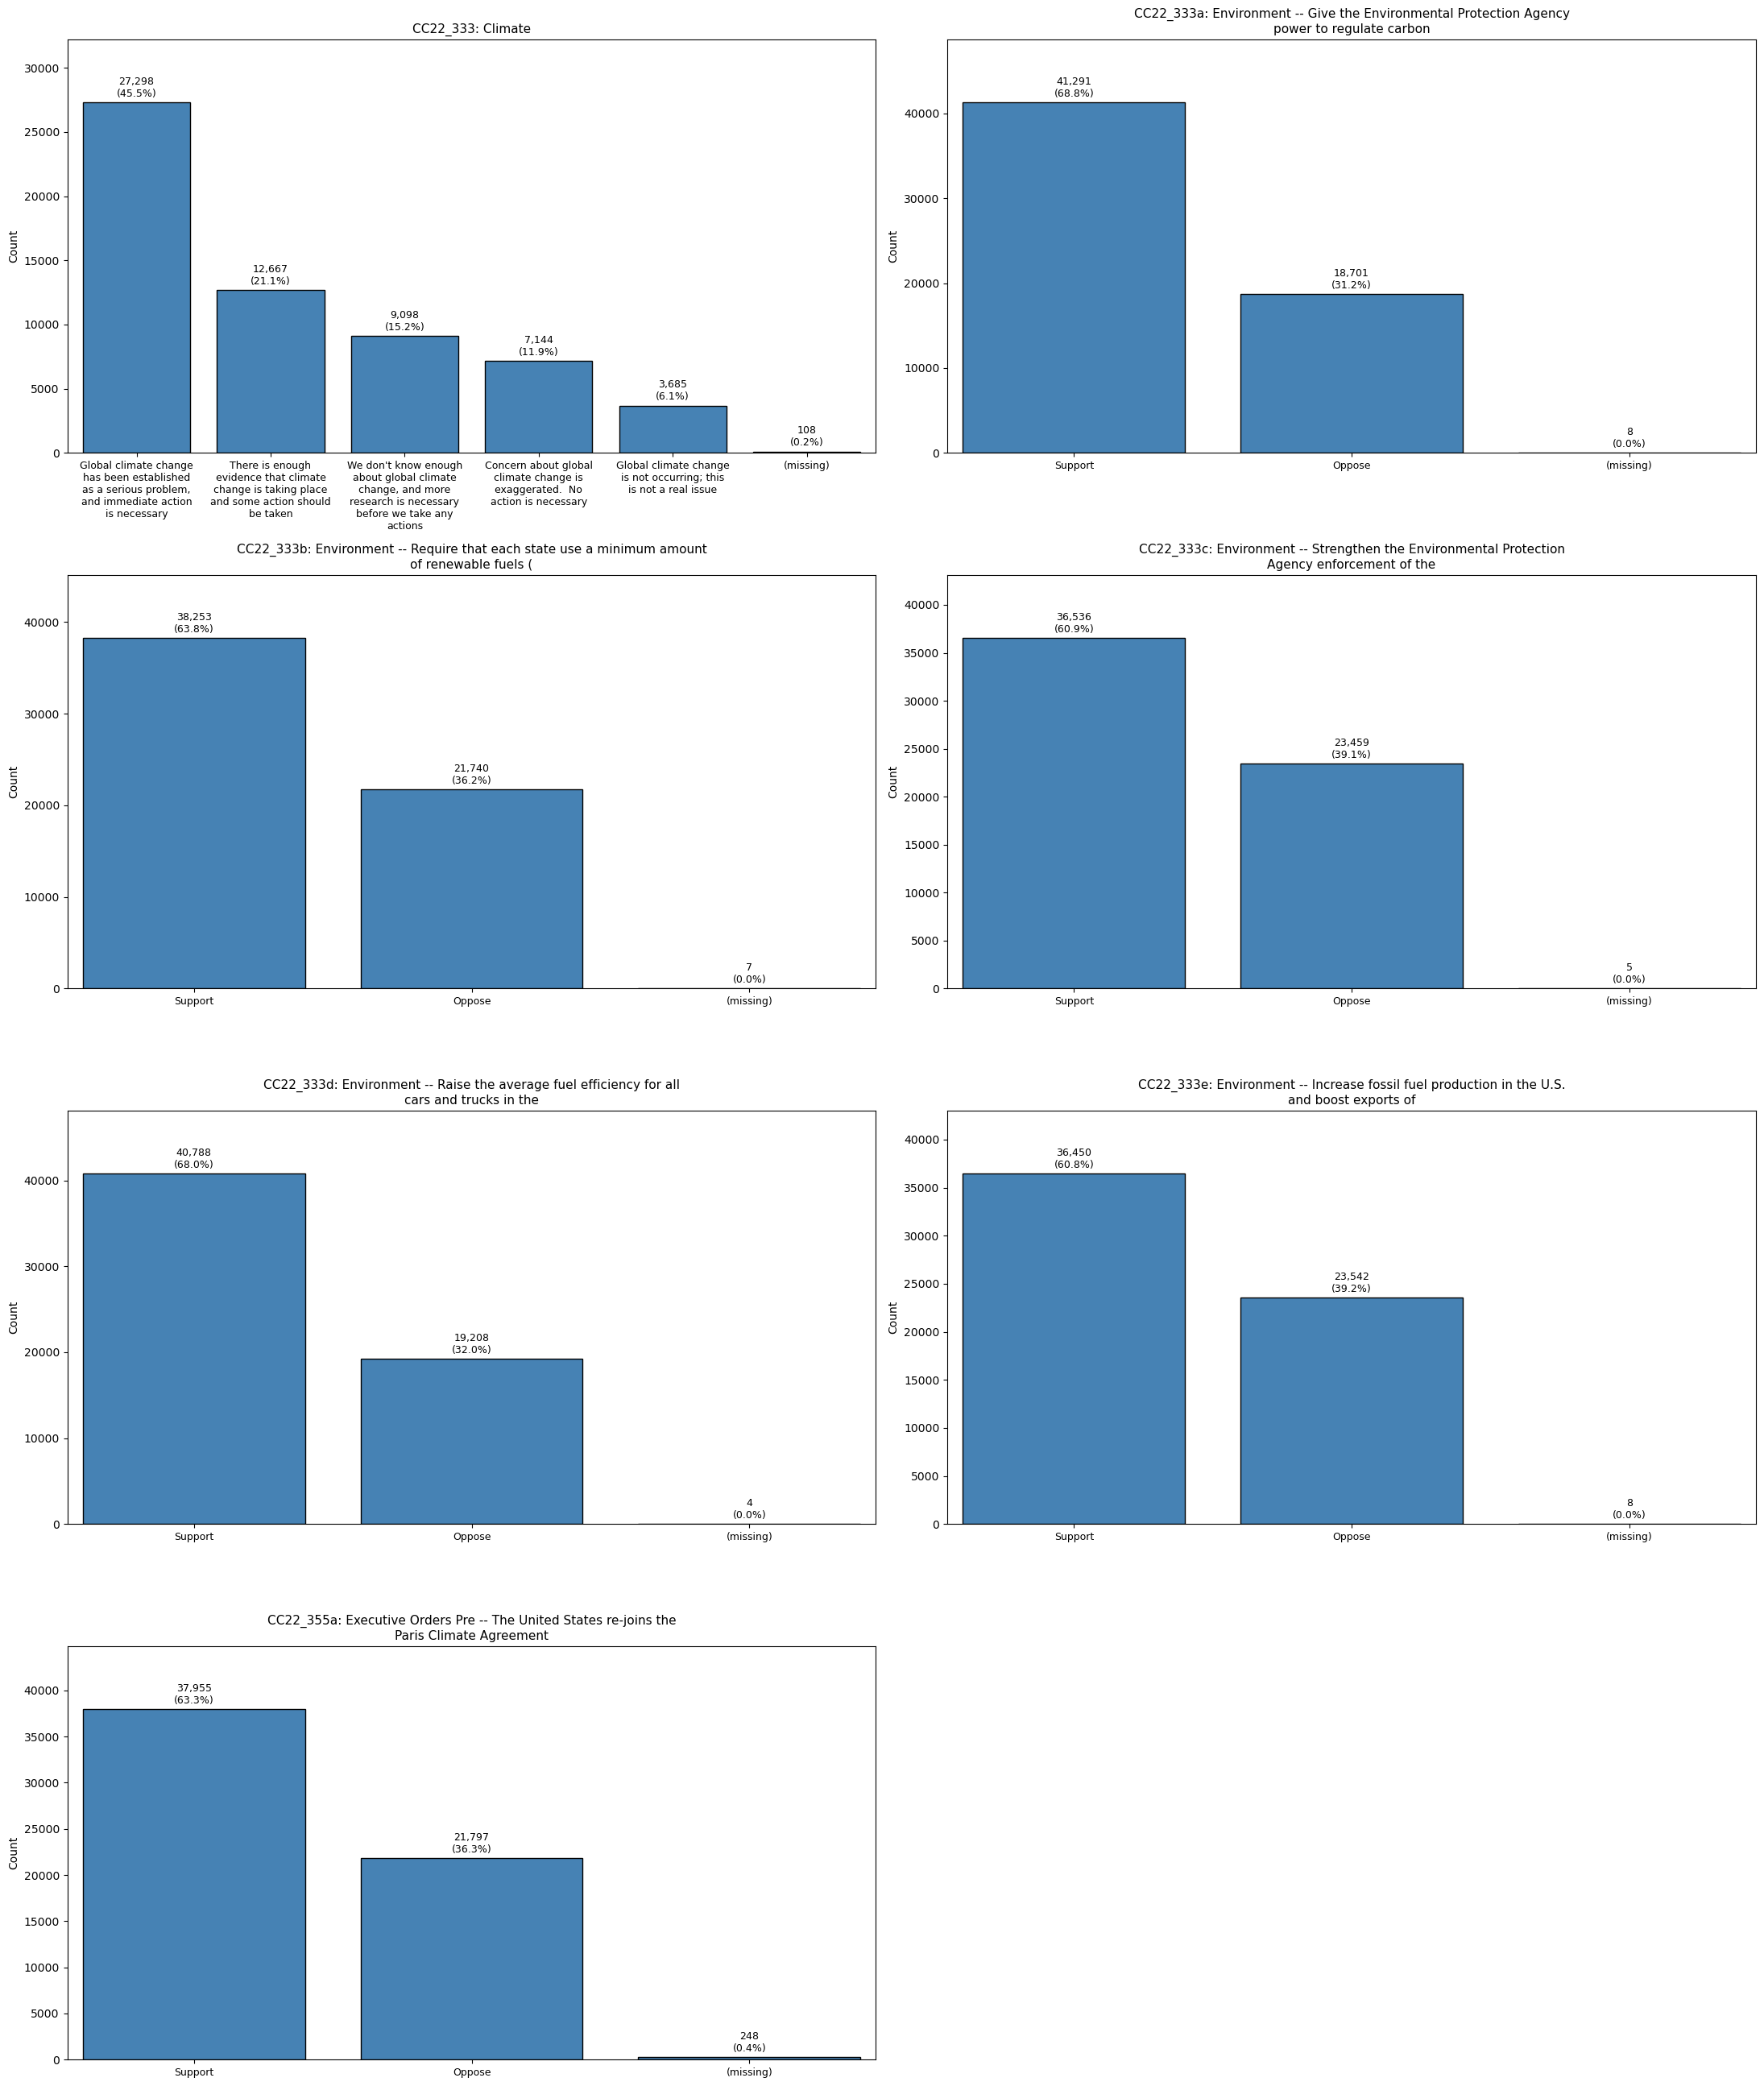

In [4]:
DTA = "filtered_responses_preprocessing.dta"

df = pd.read_stata(DTA)

cc_cols = [c for c in df.columns if c.startswith("CC22_")]
n = len(cc_cols)
ncols = 2
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(11 * ncols, 6.5 * nrows))
axes = axes.flatten()

for ax, col in zip(axes, cc_cols):
    counts = df[col].value_counts(dropna=False)
    if isinstance(df[col].dtype, pd.CategoricalDtype):
        order = df[col].cat.categories.tolist()
        if df[col].isna().any():
            order = order + [float("nan")]
        counts = counts.reindex(order).fillna(0).astype(int)

    total = counts.sum()
    pcts = counts / total * 100
    labels = ["(missing)" if pd.isna(x) else str(x) for x in counts.index]
    wrapped = [textwrap.fill(lbl, width=22) for lbl in labels]

    bars = ax.bar(range(len(counts)), counts.values,
                  color="steelblue", edgecolor="black")

    ymax = counts.values.max()
    for bar, c, p in zip(bars, counts.values, pcts.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + ymax * 0.01,
                f"{c:,}\n({p:.1f}%)",
                ha="center", va="bottom", fontsize=9)

    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(wrapped, rotation=0, ha="center", fontsize=9)
    ax.set_ylabel("Count")
    ax.set_ylim(0, ymax * 1.18)  # headroom for the count/% labels
    ax.margins(x=0.02)

    qtext = questions.get(col, "")
    title = f"{col}: {qtext}" if qtext else col
    ax.set_title(textwrap.fill(title, width=70), fontsize=11)

for ax in axes[n:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

In [13]:
700/3298000

0.00021224984839296544

In [7]:



state_tbl = (
    dat.groupby(["state_fips", "state_name", "state_pop"], dropna=False)
      .size()
      .rename("n_surveyed")
      .reset_index()
)
state_tbl["proportion_surveyed"] = state_tbl["n_surveyed"] / state_tbl["state_pop"]
state_tbl = state_tbl.sort_values("proportion_surveyed", ascending=False)
state_tbl = state_tbl[["state_name", "state_pop", "n_surveyed", "proportion_surveyed"]]

# --- County table ---
county_tbl = (
    dat.groupby(["county_fips", "county_name", "state_name", "county_pop"], dropna=False)
      .size()
      .rename("n_surveyed")
      .reset_index()
)
county_tbl["proportion_surveyed"] = county_tbl["n_surveyed"] / county_tbl["county_pop"]
county_tbl = county_tbl.sort_values("proportion_surveyed", ascending=False)
county_tbl = county_tbl[
    ["county_name", "state_name", "county_pop", "n_surveyed", "proportion_surveyed"]
]

In [9]:
state_tbl.head(10)

,state_name,state_pop,n_surveyed,proportion_surveyed
48,West Virginia,1774003.0,458,0.000258
8,District Of Columbia,674501.0,165,0.000245
38,Pennsylvania,12984655.0,3106,0.000239
19,Maine,1391585.0,323,0.000232
37,Oregon,4245964.0,970,0.000228
2,Arizona,7370065.0,1625,0.000220
7,Delaware,1020279.0,223,0.000219
35,Ohio,11764950.0,2515,0.000214
49,Wisconsin,5903472.0,1253,0.000212
25,Missouri,6179285.0,1297,0.000210


In [15]:
county_tbl = (
    county_tbl
    .query("proportion_surveyed > .000212249848392965440")
    .sort_values("proportion_surveyed", ascending=False)
)
county_tbl.head(20)

,county_name,state_name,county_pop,n_surveyed,proportion_surveyed
1607,New York,New York,1593919.0,494,0.000310
322,Marion,Florida,397075.0,120,0.000302
1938,Lane,Oregon,386268.0,116,0.000300
95,Pima,Arizona,1058224.0,296,0.000280
333,Pinellas,Florida,964496.0,267,0.000277
1839,Summit,Ohio,535956.0,147,0.000274
1955,Allegheny,Pennsylvania,1233325.0,334,0.000271
345,Volusia,Florida,580529.0,154,0.000265
1944,Multnomah,Oregon,796165.0,207,0.000260
2666,Milwaukee,Wisconsin,921471.0,236,0.000256
